<a href="https://colab.research.google.com/github/gabrielaaguiv5/ProyectoFinal2/blob/main/notebooks/AnalisisExportacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# =========================================================
# SmartChat Insight
# Análisis de clientes recurrentes, perdidos y productos más solicitados
# =========================================================

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Definir rutas
clean_path = Path("../data/cleaned/whatsapp_clean.csv")
output_path = Path("../data/outputs/")
output_path.mkdir(parents=True, exist_ok=True)

# Cargar datos limpios
df = pd.read_csv(clean_path)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Datos cargados correctamente")
print(f"Total de mensajes: {len(df)}")
df.head(5)


Datos cargados correctamente
Total de mensajes: 44993


,date,time,user,message,file_name
0,2025-10-25,12:47 p. m.,+1 (772) 800-8661,Hola!,Chat de WhatsApp con +1 (772) 800-8661.txt
1,2025-10-25,12:47 p. m.,Vidrios Y Fachadas,"Bienvenido, conoce nuestra variedad de productos:",Chat de WhatsApp con +1 (772) 800-8661.txt
2,2025-10-25,12:47 p. m.,+1 (772) 800-8661,Estoy buscando ventanas corredizas en aluminio...,Chat de WhatsApp con +1 (772) 800-8661.txt
3,2025-10-25,3:00 p. m.,Vidrios Y Fachadas,Si señor,Chat de WhatsApp con +1 (772) 800-8661.txt
4,2025-10-25,3:00 p. m.,Vidrios Y Fachadas,Se las tenemos,Chat de WhatsApp con +1 (772) 800-8661.txt


In [44]:
# Identificar participantes únicos
clientes = df["user"].unique()
print(f"Total de usuarios detectados: {len(clientes)}")

# Fecha de corte del reporte (última fecha del dataset)
fecha_corte = df["date"].max().date()
print(f"Fecha de corte del reporte: {fecha_corte}")

# Calcular número de mensajes, primera y última fecha
activity = (
    df.groupby("user")
      .agg(
          mensajes=("message", "count"),
          primer_contacto=("date", "min"),
          ultimo_contacto=("date", "max")
      )
      .reset_index()
)

# Calcular días desde el último mensaje usando fecha de corte
activity["dias_desde_ultimo"] = (pd.to_datetime(fecha_corte) - activity["ultimo_contacto"]).dt.days

# Clasificar clientes
def clasificar_cliente(dias):
    if dias <= 15:
        return "Frecuente"
    elif dias <= 45:
        return "Inactivo reciente"
    else:
        return "Perdido"

activity["estado"] = activity["dias_desde_ultimo"].apply(clasificar_cliente)

REGLAS = {
    "Perdido": "Campaña de reactivación",
    "Inactivo reciente": "Mensaje de seguimiento",
    "Frecuente": "Mantener flujo de comunicación"
}

def accion_recomendada(estado):
    return REGLAS.get(estado, "Revisar")

activity["accion_recomendada"] = activity["estado"].apply(accion_recomendada)

activity.head(10)



Total de usuarios detectados: 313
Fecha de corte del reporte: 2025-10-27


,user,mensajes,primer_contacto,ultimo_contacto,dias_desde_ultimo,estado,accion_recomendada
0,+1 (772) 800-8661,9,2025-10-25,2025-10-27,0,Frecuente,Mantener flujo de comunicación
1,+34 610 94 76 16,9,2025-10-22,2025-10-22,5,Frecuente,Mantener flujo de comunicación
2,+51 924 523 653,6,2025-08-04,2025-08-05,83,Perdido,Campaña de reactivación
3,+57 300 2258585,8,2025-09-18,2025-10-02,25,Inactivo reciente,Mensaje de seguimiento
4,+57 300 3542763,8,2025-09-25,2025-09-26,31,Inactivo reciente,Mensaje de seguimiento
5,+57 300 3580743,9,2025-09-03,2025-10-15,12,Frecuente,Mantener flujo de comunicación
6,+57 300 3861858,2,2025-10-17,2025-10-17,10,Frecuente,Mantener flujo de comunicación
7,+57 300 5157021,1,2025-08-06,2025-08-06,82,Perdido,Campaña de reactivación
8,+57 300 5215647,4,2025-08-29,2025-08-29,59,Perdido,Campaña de reactivación
9,+57 300 5251823,2,2025-08-27,2025-08-27,61,Perdido,Campaña de reactivación


In [45]:
# Palabras clave de productos (se adaptan según cada negocio)
productos = [
    "vidrio", "fachada", "aluminio", "puerta", "ventana",
    "baño", "división", "pasamanos", "pérgola", "instalador"
]

# Contar menciones de cada producto
conteo_productos = {}
for p in productos:
    conteo_productos[p] = df["message"].str.contains(p, case=False, na=False).sum()

df_productos = pd.DataFrame(list(conteo_productos.items()), columns=["producto", "menciones"])
df_productos = df_productos.sort_values(by="menciones", ascending=False)
df_productos


,producto,menciones
0,vidrio,667
3,puerta,467
4,ventana,420
1,fachada,248
7,pasamanos,175
2,aluminio,81
9,instalador,53
5,baño,48
8,pérgola,6
6,división,5


In [46]:
# Contar menciones por cliente
menciones = []
for user, mensajes in df.groupby("user"):
    registro = {"user": user}
    for p in productos:
        registro[p] = mensajes["message"].str.contains(p, case=False, na=False).sum()
    menciones.append(registro)

df_clientes_productos = pd.DataFrame(menciones)

# Determinar producto preferido y número de menciones
df_clientes_productos["producto_preferido"] = df_clientes_productos[productos].idxmax(axis=1)
df_clientes_productos["menciones_producto_preferido"] = df_clientes_productos.apply(
    lambda row: row[row["producto_preferido"]], axis=1
)

# Unir con la tabla de actividad
clientes_final = activity.merge(df_clientes_productos[["user", "producto_preferido", "menciones_producto_preferido"]], on="user", how="left")

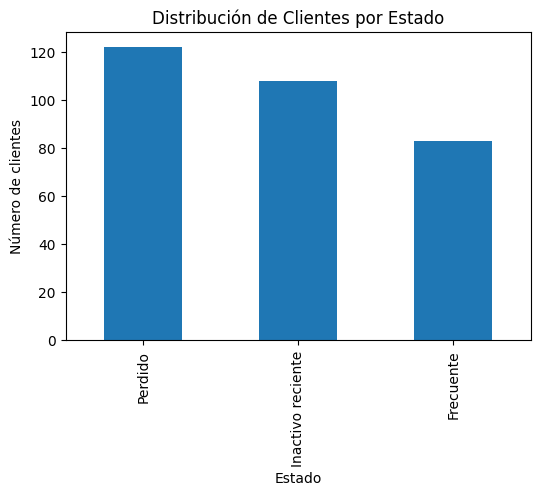

<Figure size 800x400 with 0 Axes>

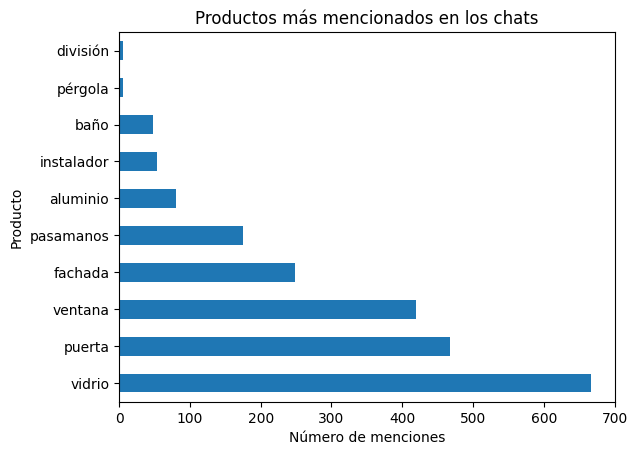

In [47]:
# Gráfico de clientes según estado
plt.figure(figsize=(6,4))
activity["estado"].value_counts().plot(kind="bar")
plt.title("Distribución de Clientes por Estado")
plt.xlabel("Estado")
plt.ylabel("Número de clientes")
plt.show()

# Gráfico de productos más mencionados
plt.figure(figsize=(8,4))
df_productos.plot(kind="barh", x="producto", y="menciones", legend=False)
plt.title("Productos más mencionados en los chats")
plt.xlabel("Número de menciones")
plt.ylabel("Producto")
plt.show()


In [48]:
activity.to_csv(output_path / "clientes.csv", index=False, encoding="utf-8-sig")
df_productos.to_csv(output_path / "productos.csv", index=False, encoding="utf-8-sig")

print("✅ Archivos exportados para Power BI:")
print(f"- {output_path / 'clientes.csv'}")
print(f"- {output_path / 'productos.csv'}")

✅ Archivos exportados para Power BI:
- ..\data\outputs\clientes.csv
- ..\data\outputs\productos.csv


In [49]:
# =========================================================
# SmartChat Insight
# Exportación y preparación de datasets finales para Power BI
# =========================================================

# Importar librerías
import pandas as pd
from pathlib import Path

# Rutas de entrada y salida
input_path = Path("../data/outputs/")
final_path = Path("../data/outputs/final/")
final_path.mkdir(parents=True, exist_ok=True)

# Cargar archivos de análisis previos
clientes = pd.read_csv(input_path / "clientes.csv")
productos = pd.read_csv(input_path / "productos.csv")

print(f"Clientes cargados: {len(clientes)} registros")
print(f"Productos cargados: {len(productos)} registros")

clientes.head(5)

Clientes cargados: 313 registros
Productos cargados: 10 registros


,user,mensajes,primer_contacto,ultimo_contacto,dias_desde_ultimo,estado,accion_recomendada
0,+1 (772) 800-8661,9,2025-10-25,2025-10-27,0,Frecuente,Mantener flujo de comunicación
1,+34 610 94 76 16,9,2025-10-22,2025-10-22,5,Frecuente,Mantener flujo de comunicación
2,+51 924 523 653,6,2025-08-04,2025-08-05,83,Perdido,Campaña de reactivación
3,+57 300 2258585,8,2025-09-18,2025-10-02,25,Inactivo reciente,Mensaje de seguimiento
4,+57 300 3542763,8,2025-09-25,2025-09-26,31,Inactivo reciente,Mensaje de seguimiento


In [50]:
# Normalizar nombres de columnas a formato uniforme para Power BI
clientes.columns = clientes.columns.str.lower().str.replace(" ", "_")
productos.columns = productos.columns.str.lower().str.replace(" ", "_")

# Asegurar tipos de datos correctos
clientes["primer_contacto"] = pd.to_datetime(clientes["primer_contacto"], errors="coerce")
clientes["ultimo_contacto"] = pd.to_datetime(clientes["ultimo_contacto"], errors="coerce")
clientes["dias_desde_ultimo"] = clientes["dias_desde_ultimo"].astype(int)

In [51]:
# Crear un resumen con totales por estado
resumen_clientes = (
    clientes.groupby("estado")
    .agg(
        total_clientes=("user", "count"),
        promedio_mensajes=("mensajes", "mean"),
        dias_promedio_inactividad=("dias_desde_ultimo", "mean")
    )
    .reset_index()
)

# Agregar fecha de generación del reporte
from datetime import datetime
resumen_clientes["fecha_reporte"] = datetime.now().strftime("%Y-%m-%d")
resumen_clientes


,estado,total_clientes,promedio_mensajes,dias_promedio_inactividad,fecha_reporte
0,Frecuente,83,439.602410,6.987952,2025-11-16
1,Inactivo reciente,108,40.092593,28.962963,2025-11-16
2,Perdido,122,34.229508,81.655738,2025-11-16


In [52]:
clientes.to_csv(final_path / "clientes_powerbi.csv", index=False, encoding="utf-8-sig", sep=";")
productos.to_csv(final_path / "productos_powerbi.csv", index=False, encoding="utf-8-sig", sep=";")
resumen_clientes.to_csv(final_path / "resumen_clientes.csv", index=False, encoding="utf-8-sig", sep=";")
clientes_final.to_csv(final_path / "clientes_final_powerbi.csv", index=False, encoding="utf-8-sig", sep=";")

print("Archivos finales generados:")
for file in final_path.glob("*.csv"):
    print(f"- {file}")

Archivos finales generados:
- ..\data\outputs\final\clientes_final_powerbi.csv
- ..\data\outputs\final\clientes_powerbi.csv
- ..\data\outputs\final\productos_powerbi.csv
- ..\data\outputs\final\resumen_clientes.csv
